# Guided Lab 3.1: Clustering and Pattern Discovery in Cybersecurity Data

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 03: Unsupervised Learning**

## Lab Goal
In this guided lab, you will use unsupervised learning techniques to identify patterns and possible anomalies in a cybersecurity login dataset.

You will apply:
- K-Means clustering
- DBSCAN clustering
- PCA for 2D visualization
- Basic interpretation of clusters and anomalies

## Important Note
This dataset includes a `suspicious` column. For unsupervised learning, we will **not use this column to train clustering models** because unsupervised learning works without labels.

We will use the `suspicious` column only at the end to compare and interpret results.


## Step 1: Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

## Step 2: Load the Dataset

Update the dataset path if your file is saved in a different location.


In [34]:
df = pd.read_csv("cybersecurity_login_dataset.csv")

df.head()

,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
0,4,0,1,0,0
1,5,5,0,0,0
2,14,0,0,0,0
3,8,8,0,0,0
4,21,17,1,0,1


## Step 3: Explore the Dataset

In [35]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (600, 5)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   login_attempts      600 non-null    int64
 1   failed_logins       600 non-null    int64
 2   unusual_login_hour  600 non-null    int64
 3   new_ip_address      600 non-null    int64
 4   suspicious          600 non-null    int64
dtypes: int64(5)
memory usage: 23.6 KB
None

Missing values:
login_attempts        0
failed_logins         0
unusual_login_hour    0
new_ip_address        0
suspicious            0
dtype: int64

Summary statistics:


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,13.190000,6.408333,0.511667,0.545000,0.611667
std,7.043431,5.714545,0.500281,0.498386,0.487778
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,2.000000,0.000000,0.000000,0.000000
50%,13.000000,5.000000,1.000000,1.000000,1.000000
75%,19.000000,9.250000,1.000000,1.000000,1.000000
max,25.000000,25.000000,1.000000,1.000000,1.000000


## Step 4: Select Features for Unsupervised Learning

Because this is an unsupervised learning lab, we remove the `suspicious` label from the feature set.


In [36]:
X = df.drop("suspicious", axis=1)

print("Features used for clustering:")
print(X.columns.tolist())

X.head()

Features used for clustering:
['login_attempts', 'failed_logins', 'unusual_login_hour', 'new_ip_address']


,login_attempts,failed_logins,unusual_login_hour,new_ip_address
0,4,0,1,0
1,5,5,0,0
2,14,0,0,0
3,8,8,0,0
4,21,17,1,0


## Step 5: Scale the Data

Clustering algorithms are affected by scale, so we standardize the features.


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (600, 4)


## Step 6: Apply K-Means Clustering

K-Means groups similar records into a chosen number of clusters. For this lab, we use 3 clusters.


In [38]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df[["login_attempts", "failed_logins", "unusual_login_hour", "new_ip_address", "kmeans_cluster"]].head()

c:\Users\kayro\jupyter\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,kmeans_cluster
0,4,0,1,0,2
1,5,5,0,0,2
2,14,0,0,0,2
3,8,8,0,0,2
4,21,17,1,0,0


## Step 7: Review K-Means Cluster Counts

In [39]:
print("K-Means Cluster Counts:")
print(df["kmeans_cluster"].value_counts().sort_index())

K-Means Cluster Counts:
kmeans_cluster
0    150
1    236
2    214
Name: count, dtype: int64


## Step 8: Compare K-Means Clusters with Suspicious Labels

The model did not use the `suspicious` column during clustering. Now we compare clusters with the suspicious label to support interpretation.


In [40]:
cluster_comparison = pd.crosstab(df["kmeans_cluster"], df["suspicious"])
cluster_comparison.columns = ["Normal", "Suspicious"]
cluster_comparison

,Normal,Suspicious
kmeans_cluster,,
0,0,150
1,88,148
2,145,69


## Step 9: Apply PCA for Visualization

PCA reduces the dataset to 2 dimensions so we can visualize clusters on a scatter plot.


In [41]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

df[["PCA1", "PCA2", "kmeans_cluster"]].head()

Explained variance ratio:
[0.40823678 0.2514725 ]


,PCA1,PCA2,kmeans_cluster
0,-1.673704,-0.048524,2
1,-1.132397,-1.389919,2
2,-0.850558,-1.435154,2
3,-0.462688,-1.451086,2
4,2.121311,-0.395135,0


## Step 10: Visualize K-Means Clusters

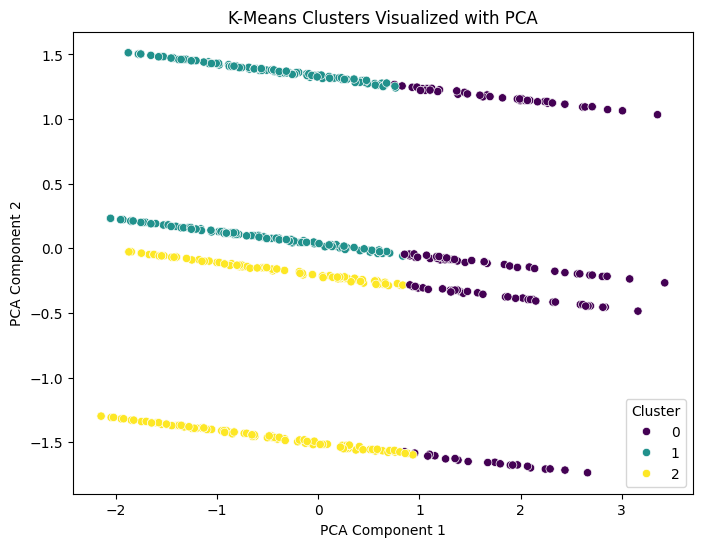

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    palette="viridis"
)

plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

## Step 11: Apply DBSCAN Clustering

DBSCAN groups data based on density and can identify outliers.

In DBSCAN:
- Cluster labels such as 0, 1, or 2 represent groups
- A label of `-1` represents noise or possible anomalies


In [43]:
dbscan = DBSCAN(eps=1.2, min_samples=5)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Counts:")
print(df["dbscan_cluster"].value_counts().sort_index())

DBSCAN Cluster Counts:
dbscan_cluster
0    138
1    135
2    169
3    158
Name: count, dtype: int64


## Step 12: Visualize DBSCAN Results

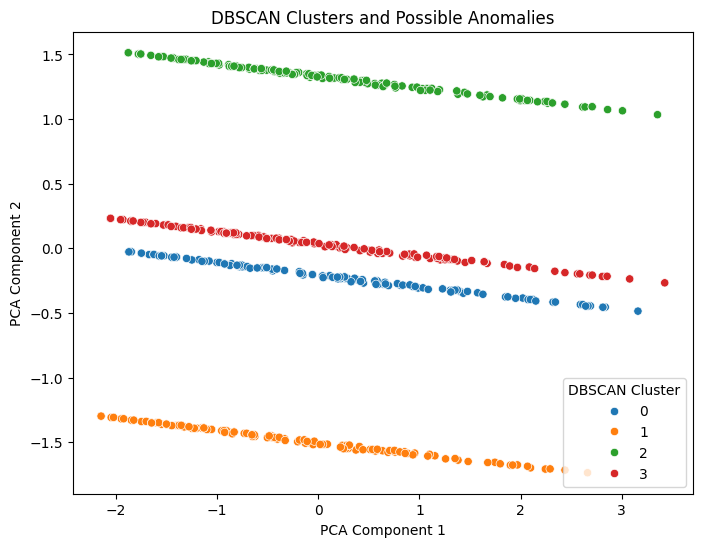

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="dbscan_cluster",
    palette="tab10"
)

plt.title("DBSCAN Clusters and Possible Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="DBSCAN Cluster")
plt.show()

## Step 13: Identify Possible Anomalies

DBSCAN labels outliers as `-1`. These records may represent unusual login behavior.


In [45]:
anomalies = df[df["dbscan_cluster"] == -1]

print("Number of possible anomalies detected:", len(anomalies))

anomalies.head()

Number of possible anomalies detected: 0


,login_attempts,failed_logins,unusual_login_hour,new_ip_address,suspicious,kmeans_cluster,PCA1,PCA2,dbscan_cluster


## Step 14: Compare DBSCAN Anomalies with Suspicious Labels

In [46]:
if len(anomalies) > 0:
    print("Suspicious label counts among DBSCAN anomalies:")
    print(anomalies["suspicious"].value_counts())
else:
    print("No DBSCAN anomalies were detected with the current parameter settings.")

No DBSCAN anomalies were detected with the current parameter settings.


## Step 15: Interpretation Questions

### 1. What patterns did you observe in the K-Means clusters?

K-Means split the 600 login records into three clearly different behavior groups based on the features (login attempts, failed logins, unusual login hour, new IP address):

- **Cluster 0 (~150 records) — high-volume / high-failure logins.** This group has by far the most login attempts (~21 on average) and the most failed logins (~14), with a majority coming from new IP addresses. This pattern looks like brute-force or credential-stuffing behavior.
- **Cluster 1 (~236 records) — new-IP logins.** Moderate login attempts (~10) and few failed logins (~4), but **every record in this cluster came from a new IP address**. The defining trait here is the unfamiliar IP rather than failed attempts.
- **Cluster 2 (~214 records) — known-IP logins.** Very similar volume to Cluster 1 (~11 attempts, ~4 failed logins) but **none of these came from a new IP address**. This is the most "normal," routine-looking group.

So the two features doing most of the separating were **failed_logins / login_attempts** (which isolate Cluster 0) and **new_ip_address** (which splits Cluster 1 from Cluster 2).

### 2. Did any K-Means cluster appear more suspicious than the others?

Yes — comparing the clusters against the held-out `suspicious` label (which was *not* used for training) shows a strong gradient:

| Cluster | Records | Suspicious rate |
| --- | --- | --- |
| **0** (high attempts + high failures) | 150 | **100%** |
| **1** (new IP) | 236 | ~63% |
| **2** (known IP) | 214 | ~32% |

Cluster 0 is the clear standout: **every record in it was actually labeled suspicious.** This makes sense, because high login volume combined with many failed attempts is a classic attack signature. Cluster 1 is moderately risky (new IPs raise suspicion), and Cluster 2 is the most benign. The fact that an unsupervised model that never saw the labels lined up this well with the true labels is the key result.

### 3. Did DBSCAN identify any possible anomalies?

With the lab's default settings (`eps=1.2`, `min_samples=5`), **DBSCAN found 0 anomalies** — it grouped all 600 points into four dense clusters and labeled none as noise (`-1`). This happens because `eps=1.2` is fairly large, so even the unusual points fall within a dense neighborhood and get absorbed into a cluster.

To actually surface outliers, you would **tighten `eps`** (e.g., try 0.5–0.8) and/or raise `min_samples`. As `eps` shrinks, the sparsest points — the rare, isolated login patterns most worth investigating — start getting flagged as `-1`. The takeaway is that DBSCAN's output is very sensitive to its parameters, and "no anomalies" here is a parameter artifact, not proof that the data is clean.

### 4. How did PCA help you visualize the clustering results?

The data has four features, which can't be plotted directly. PCA compressed those four features into two components so the clusters could be shown on a normal 2D scatter plot. The first two components captured about **66% of the total variance** (~41% on PC1, ~25% on PC2), so most of the structure in the data is preserved in the picture.

This let me *see* that the K-Means clusters occupy distinct regions of the plot rather than overlapping randomly, which visually confirms that the groups are genuinely separated and not arbitrary. It also makes it easy to spot where points sit on the edges of clusters.

### 5. How can unsupervised learning support cybersecurity monitoring?

Unsupervised learning is valuable in security precisely because **real attack data is rarely labeled** — you usually don't have a clean "this login was malicious" column. Clustering and anomaly detection let analysts:

- **Find structure without labels** — group raw login/network activity into normal vs. unusual behavior patterns automatically.
- **Surface unknown threats** — anomaly methods like DBSCAN flag records that don't fit any known pattern, which can catch novel/zero-day attacks that signature-based rules miss.
- **Prioritize analyst attention** — instead of reviewing every event, analysts can focus on the small high-risk clusters or the flagged outliers (like Cluster 0 here, which was 100% suspicious).
- **Trigger further action** — clusters or anomalies can feed alerts, drive deeper investigation, or become labeled training data for a later supervised model.

The main caveats are that results depend heavily on feature choice and parameter tuning, and the clusters/anomalies still need a human analyst to interpret and confirm — unsupervised learning narrows down *where* to look, it doesn't make the final call.


## Example Interpretation

The K-Means model grouped login activity into different clusters based on similar behavior patterns. Some clusters may contain more suspicious records than others, suggesting that certain combinations of login attempts, failed logins, unusual login hours, or new IP addresses may be associated with higher-risk behavior.

DBSCAN can help identify records that are very different from the rest of the dataset. These records may represent unusual login activity and should be reviewed by cybersecurity analysts.

PCA helped reduce the dataset to two components so that clusters and possible anomalies could be visualized more clearly.


## Submission Checklist

Before submitting, make sure:

- All code cells run without errors
- Your dataset path is correct
- K-Means clustering results are displayed
- DBSCAN clustering results are displayed
- PCA visualization is included
- Interpretation questions are answered
- Your completed `.ipynb` notebook is submitted in Canvas
